In [70]:
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
def get_demod_freq(SensTqp: int):
    freq_demod = (70 * 1e6 / 8) * (1 / (SensTqp + 30))
    return freq_demod  # Hz

def get_tqp(demod_freq):
    tqp = 70 * 1e6 / (8 * demod_freq) - 30
    return int(tqp)

In [ ]:

files = glob.glob('results/manual_search/*.npz')
print(f"Found {len(files)} result files")

rows = []
for f in files:
    # Soapbox: Use context managers!
    with np.load(f) as data:
        nf, nm, tq = data['settings']
        times = data['times']
        failed_arr = data['failed_arr']
        powers_of_ten = data['powers_of_ten']
        rows.append({
            'NFrames': int(nf),
            'NavM2': int((nm - 2) / 2),
            'Tqp': int(tq),
            'transfer times (s)': np.mean(times)/10**6 if len(times) > 0 else [],
            # 'durations (s)': powers_of_ten / 100e6,
            # 'failed_arr': failed_arr,
            'success_times (s)':  powers_of_ten[~failed_arr] / 100e6,
            'fps_higher_than_spec' : get_demod_freq(tq) / nm >= 3800
        })

df = pd.DataFrame(rows)#.sort_values(['NFrames', 'NavM2'])
display(df)


Found 13 result files


,NFrames,NavM2,Tqp,transfer times (s),success_times (s),fps_higher_than_spec
0,1,200,1,26.663033,"[10.0, 1.0, 0.1]",False
1,1,200,4095,25.63742,"[10.0, 1.0]",False
2,1,1,1,26.26495,"[10.0, 1.0, 0.1]",True
3,1,1,4095,24.808675,"[10.0, 1.0, 0.1]",False
4,200,200,1,87.06965,[10.0],False
5,200,200,4095,114.7155,[],False
6,200,1,1,[],[],True
7,200,1,4095,89.932525,[10.0],False
8,500,200,1,158.55465,[10.0],False
9,500,200,4095,[],[],False


AxesImage(shape=(300, 300))


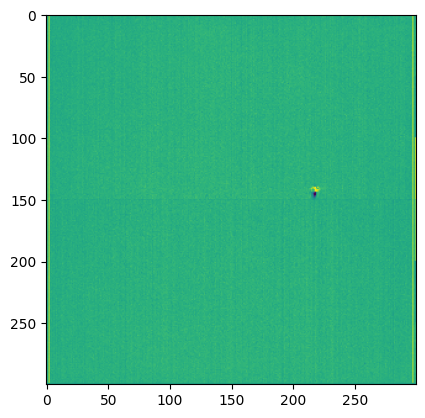

In [ ]:
# Sanity check that a given run produced an actual image
with np.load('results/binary_search/f1_d402_t4095.npz') as c:
    print(plt.imshow(c['images'][0]))

In [74]:
files = glob.glob("results/binary_search/*.npz")
print(f"Found {len(files)} result files")

rows = []
for f in files:
    with np.load(f) as data:
    # data = np.load(f)
        nf, nm, tq = data["settings"]
        fastest_time = data["fastest_time"]
        if fastest_time == "None":
            fastest_time = 0
        iters = data["iters"]
        tolerance = data["tolerance"]
        acq_times = data["acquisition_times"]
        duration = data["duration"]
        times_to_test = data["times_to_test"]
        rows.append(
            {
                "NFrames": int(nf),
                "NavM2": int((nm - 2) / 2),
                "Tqp": int(tq),
                "fastest_time (s)": fastest_time,
                "acq_rate" : 1/fastest_time if fastest_time != 0 else 0,
                "calc_fps" : int(nf)/fastest_time if fastest_time != 0 else 0,
                "tol (s)": tolerance,
                "iters": int(iters),
                "acq_times (ns)": acq_times,
                'fps_higher_than_spec' : get_demod_freq(tq) / nm >= 3800
                # 'duration' : duration
            }
        )

# df = pd.DataFrame(rows).sort_values(['NFrames'])
df = pd.DataFrame(rows).sort_values(['fastest_time (s)'])
# df = pd.DataFrame(rows)
display(df)


Found 27 result files


,NFrames,NavM2,Tqp,fastest_time (s),acq_rate,calc_fps,tol (s),iters,acq_times (ns),fps_higher_than_spec
20,500,50,4095,0,0.000000,0.000000,0.5,5,[],False
24,500,1,1,0,0.000000,0.000000,0.5,5,[],True
2,100,50,4095,0,0.000000,0.000000,0.5,5,[],False
23,500,200,4095,0,0.000000,0.000000,0.001,14,[],False
4,100,200,2000,0,0.000000,0.000000,0.5,5,[],False
5,100,200,4095,0,0.000000,0.000000,0.5,5,[],False
6,100,1,1,0,0.000000,0.000000,0.001,14,[],True
22,500,200,2000,0,0.000000,0.000000,0.5,5,[],False
19,500,50,2000,0,0.000000,0.000000,0.5,5,[],False
16,1,1,2000,0.02358074,42.407490,42.407490,0.001,14,"[1032445400, 31711600, 31466800]",False


In [77]:
nonzero_df = df[df['fastest_time (s)'] != 0]
nonzero_df

,NFrames,NavM2,Tqp,fastest_time (s),acq_rate,calc_fps,tol (s),iters,acq_times (ns),fps_higher_than_spec
16,1,1,2000,0.02358074,42.407490,42.407490,0.001,14,"[1032445400, 31711600, 31466800]",False
12,1,200,1,0.02419103,41.337636,41.337636,0.001,14,"[1034492000, 32285300]",False
15,1,1,1,0.02419103,41.337636,41.337636,0.001,14,"[1015212600, 32297200]",True
9,1,50,1,0.0260219,38.429169,38.429169,0.001,14,"[1022596500, 31506300, 31654600]",False
10,1,50,2000,0.03639684,27.474913,27.474913,0.001,14,"[48035300, 33334200]",False
11,1,50,4095,0.05836729,17.132884,17.132884,0.001,14,"[98980000, 113669300]",False
13,1,200,2000,0.10413908,9.602543,9.602543,0.001,14,"[198533100, 100250500, 95423300]",False
14,1,200,4095,0.20056499,4.985915,4.985915,0.001,14,"[398092700, 199985100, 201830500]",False
17,1,1,4095,0.31407904,3.183912,3.183912,0.001,14,"[310467600, 310457200, 305032600]",False
0,100,50,1,1.01408226,0.986113,98.611330,0.001,14,"[1038031900, 1015093200]",False
